# 📊 Strategic Retail Analytics: EDA & RFM Segmentation

### Executive Summary
This analysis utilizes data-driven methodologies to evaluate business performance and customer health through two primary workstreams:

* **Exploratory Data Analysis (EDA):** A rigorous audit of sales trends, revenue growth, and product performance to ensure data integrity and identify commercial drivers.
* **RFM Framework:** Implementation of a Recency, Frequency, and Monetary model to quantify customer engagement and spending power.


### 🛠️ Environment Setup & Data Integration

This section establishes the analytical foundation by configuring the necessary libraries and secure data access:

* **Engine Configuration:** Installation and import of `pandasql` to enable advanced SQL querying directly on DataFrames.
* **Library Suite:** Loading of core data science libraries—`pandas` and `numpy` for data manipulation, and `matplotlib` for visualization.
* **Cloud Integration:** Mounting Google Drive to facilitate secure access to external datasets and persistent storage of analysis results.

In [ ]:
! pip install pandasql -q
import pandasql as psql
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 📂 Data Acquisition & Workspace Configuration

This stage initializes the data pipeline by importing the primary relational datasets required for the analysis:

* **Source Path Definition:** Establishing a centralized directory for modular and scalable file referencing.
* **Relational Dataset Loading:** Importing the core business entities—**Customers**, **Products**, **Orders**, and **Marketing Campaigns**—into Pandas DataFrames.
* **Data Structuring:** Preparing the raw CSV files for subsequent merging and integrity validation.

In [ ]:
folder_path = "/content/drive/MyDrive/Colab Notebooks/levels of data/level 2"
customers = pd.read_csv(f"{folder_path}/customers.csv")
products = pd.read_csv(f"{folder_path}/products.csv")
orders = pd.read_csv(f"{folder_path}/orders.csv")
campaigns = pd.read_csv(f"{folder_path}/campaigns.csv")

### 📝 SQL Query Engine Implementation

This section defines a streamlined utility function to facilitate efficient data exploration:

* **Abstraction Layer:** Encapsulates `pandasql` logic to allow for clean, direct SQL execution on existing DataFrames.
* **Namespace Integration:** Utilizes `globals()` to ensure the SQL engine automatically recognizes all DataFrames currently loaded in the environment.
* **Syntax Optimization:** Provides a simplified interface for complex joins and aggregations, bridging the gap between relational querying and Pythonic data manipulation.

In [ ]:
def sql(query):
  return psql.sqldf(query,globals())

# 🔍 Phase 1: Exploratory Data Analysis (EDA)

### 📈 High-Level Business Metrics Overview

This section initiates the exploratory phase by calculating the fundamental Key Performance Indicators (KPIs) to establish a baseline for business health:

* **Revenue Quantization:** Aggregates total gross revenue by calculating the product of quantity and unit price across all transactions.
* **Operational Volume:** Computes the total count of unique orders, customers, and product SKUs active within the dataset.
* **Integrity Validation:** Implements a `TRIM()` function on `Product_ID` during the join to mitigate data quality issues caused by trailing whitespaces, ensuring a 100% match rate between the orders and products tables.

In [ ]:
query = """

SELECT
  ROUND(SUM(o.Quantity*p.Price),2) AS Total_Revenue,
  COUNT(DISTINCT o.Order_ID) AS Total_Orders,
  COUNT(DISTINCT o.Customer_ID) AS Total_Customers,
  COUNT(DISTINCT o.Product_ID) AS Total_Products
  FROM orders as o
  LEFT JOIN products as p ON o.Product_ID = TRIM(p.Product_ID) -- THERE IS SOME WHITESPACE AT TE END OF PRODUCT_ID IN PRODUCTS TABLE

"""
result= sql(query)
result

,Total_Revenue,Total_Orders,Total_Customers,Total_Products
0,1212799.34,780,100,50


### 🌍 Geographic Performance Analysis

This analysis disaggregates core business metrics by customer location to identify high-value geographic markets:

* **Regional Revenue Distribution:** Ranks cities by total gross revenue to pinpoint the primary geographical drivers of income.
* **Customer Density vs. Volume:** Compares the number of unique customers against total orders and units sold per city to evaluate market penetration.
* **Multi-Table Integration:** Executes a complex three-way join between **Orders**, **Customers**, and **Products**, maintaining data precision through continued use of the whitespace trimming logic on product identifiers.

In [ ]:
query= """
SELECT
   c.City,
   COUNT(DISTINCT c.Customer_ID) AS Total_Customers,
   ROUND(SUM(o.Quantity*p.Price),2) AS Total_Revenue,
   COUNT(DISTINCT o.Order_ID) AS Total_Orders,
   SUM(o.Quantity) AS Total_Units
   FROM orders as o LEFT JOIN customers as c ON o.Customer_ID = c.Customer_ID
   LEFT JOIN products as p ON o.Product_ID = TRIM(p.Product_ID)
   GROUP BY c.City
   ORDER BY Total_Revenue DESC
"""
result = sql(query)
result

,City,Total_Customers,Total_Revenue,Total_Orders,Total_Units
0,Los Angeles,21,287888.03,180,2863
1,New York,23,268501.65,181,2821
2,Chicago,20,240845.15,152,2408
3,Houston,18,226424.58,139,2279
4,Philadelphia,18,189139.93,128,2047


### 📢 Acquisition Channel Efficiency Evaluation

This section analyzes the profitability and reach of different marketing channels to determine where customer acquisition is most effective:

* **Channel Monetization:** Measures the total revenue generated by each acquisition source to identify the highest-yielding marketing streams.
* **Customer Intake Volume:** Quantifies the number of unique customers acquired per channel, providing insight into market reach versus individual customer value.
* **Conversion Metrics:** Evaluates order frequency and total unit volume across channels, allowing for a comparison between high-volume "mass market" channels and high-value "niche" sources.

In [ ]:
query= """
SELECT
   c.Acquisition_Channel,
   ROUND(SUM(o.Quantity*p.Price),2) AS Total_Revenue,
   COUNT(DISTINCT c.Customer_ID) AS Total_Customers,
   COUNT(DISTINCT o.Order_ID) AS Total_Orders,
   SUM(o.Quantity) AS Total_Units
   FROM orders as o LEFT JOIN customers as c ON o.Customer_ID = c.Customer_ID
   LEFT JOIN products as p ON o.Product_ID = TRIM(p.Product_ID)
   GROUP BY c.Acquisition_Channel
   ORDER BY Total_Revenue DESC
"""
result = sql(query)
result

,Acquisition_Channel,Total_Revenue,Total_Customers,Total_Orders,Total_Units
0,paid ads,362266.57,27,225,3602
1,direct,326433.13,27,221,3499
2,search engine,305143.02,27,187,2986
3,social media,218956.62,19,147,2331


### 🏆 Top Tier Customer Identification (High-Value Analysis)

This analysis shifts from aggregate trends to individual performance by profiling the highest-contributing customers:

* **Revenue Concentration:** Identifies the top 10 customers by total gross expenditure, highlighting the individuals most critical to business revenue.
* **Purchasing Behavior:** Correlates total revenue with order frequency and unit volume to distinguish between "bulk buyers" and "high-frequency shoppers."
* **VIP Benchmarking:** Provides a foundational list for targeted loyalty programs and personalized marketing outreach, serving as a direct lead-in to the granular RFM segmentation phase.

In [ ]:
query= """
SELECT
   c.Customer_ID,
   ROUND(SUM(o.Quantity*p.Price),2) AS Total_Revenue,
   COUNT(DISTINCT o.Order_ID) AS Total_Orders,
   SUM(o.Quantity) AS Total_Units
   FROM orders as o LEFT JOIN customers as c ON o.Customer_ID = c.Customer_ID
   LEFT JOIN products as p ON o.Product_ID = TRIM(p.Product_ID)
   GROUP BY c.Customer_ID
   ORDER BY Total_Revenue DESC
   LIMIT 10
"""
result = sql(query)
result

,Customer_ID,Total_Revenue,Total_Orders,Total_Units
0,CUST_0029,27520.04,15,224
1,CUST_0090,24927.89,14,246
2,CUST_0037,24672.34,14,216
3,CUST_0080,23397.05,14,224
4,CUST_0005,22411.65,11,177
5,CUST_0059,21879.01,13,202
6,CUST_0098,19651.08,12,195
7,CUST_0069,19264.66,12,192
8,CUST_0042,19089.21,9,146
9,CUST_0003,19000.94,9,160


### 📦 Product Performance & Revenue Drivers

This section identifies the primary inventory drivers by ranking individual products based on their financial contribution:

* **Revenue Contribution:** Isolates the top 10 products by gross revenue to determine which items are the most significant contributors to the bottom line.
* **Volume vs. Value Analysis:** Examines the relationship between units sold and total revenue to distinguish between high-margin luxury items and high-turnover commodities.
* **Inventory Insights:** Provides critical data for stock prioritization and supply chain optimization by highlighting the products with the highest market demand.

In [ ]:
query= """
SELECT
   P.Product_ID,
   ROUND(SUM(o.Quantity*p.Price),2) AS Total_Revenue,
   COUNT(DISTINCT o.Order_ID) AS Total_Orders,
   SUM(o.Quantity) AS Total_Units
   FROM orders as o LEFT JOIN customers as c ON o.Customer_ID = c.Customer_ID
   LEFT JOIN products as p ON o.Product_ID = TRIM(p.Product_ID)
   GROUP BY P.Product_ID
   ORDER BY Total_Revenue DESC
   LIMIT 10
"""
result = sql(query)
result

,Product_ID,Total_Revenue,Total_Orders,Total_Units
0,PROD_0033,117665.46,106,279
1,PROD_0045,106659.37,98,241
2,PROD_0044,105103.02,104,242
3,PROD_0047,60211.80,94,220
4,PROD_0034,52734.12,113,303
5,PROD_0005,51962.02,111,251
6,PROD_0048,48126.78,104,262
7,PROD_0050,35918.10,96,251
8,PROD_0009,31976.88,106,277
9,PROD_0031,31701.60,102,272


### 📈 Comparative Growth & Year-over-Year (YoY) Analysis

This complex query establishes the historical trajectory of the business by calculating annual growth rates across key performance indicators:

* **Temporal Segmentation:** Extracts year-level data from the transaction timestamps to observe long-term macro trends.
* **Window Function Implementation:** Utilizes `LAG()` functions to perform period-over-period comparisons, enabling the calculation of revenue and order volume deltas.
* **YoY Growth Metrics:** Computes percentage growth for both **Revenue** and **Order Volume**, providing a clear view of business scalability and market momentum.
* **Customer Retention Insights:** Tracks the evolution of the active customer base year-over-year to differentiate between new acquisition-driven growth and existing customer loyalty.

In [ ]:
query = """
WITH yearly_sales AS (
  SELECT
     SUBSTR(o.Order_Date, 1, 4) AS Year,
     ROUND(SUM(o.Quantity * p.Price), 2) AS Total_Revenue,
     COUNT(DISTINCT o.Order_ID) AS Total_Orders,
     SUM(o.Quantity) AS Total_Units,
     COUNT(DISTINCT o.Customer_ID) AS Total_Customers
  FROM orders AS o
  LEFT JOIN products AS p ON TRIM(o.Product_ID) = TRIM(p.Product_ID)
  GROUP BY Year
)
SELECT
   Year,
   Total_Revenue,
   Total_Orders,
   Total_Units,
   Total_Customers,
   LAG(Total_Revenue) OVER (ORDER BY Year) AS Previous_Year_Revenue,
   LAG(Total_Orders) OVER (ORDER BY Year) AS Previous_Year_Orders,
   ROUND(
     ((Total_Revenue - LAG(Total_Revenue) OVER (ORDER BY Year))
     / LAG(Total_Revenue) OVER (ORDER BY Year)) * 100, 2
   ) AS Revenue_YoY_Growth_Pct,
   ROUND(
     ((Total_Orders - LAG(Total_Orders) OVER (ORDER BY Year))
     / CAST(LAG(Total_Orders) OVER (ORDER BY Year) AS FLOAT)) * 100, 2
   ) AS Orders_YoY_Growth_Pct
FROM yearly_sales
ORDER BY Year
"""

result_growth = sql(query)
result_growth

,Year,Total_Revenue,Total_Orders,Total_Units,Total_Customers,Previous_Year_Revenue,Previous_Year_Orders,Revenue_YoY_Growth_Pct,Orders_YoY_Growth_Pct
0,2020,19652.03,12,190,10,NaN,NaN,NaN,NaN
1,2021,60390.01,40,622,24,19652.03,12.0,207.30,233.33
2,2022,97666.67,65,1043,35,60390.01,40.0,61.73,62.50
3,2023,183838.46,105,1730,47,97666.67,65.0,88.23,61.54
4,2024,235536.83,152,2437,65,183838.46,105.0,28.12,44.76
5,2025,615715.34,406,6396,88,235536.83,152.0,161.41,167.11


### 📊 Comparative Growth Visualization (YoY Trends)

This visualization maps the historical growth trajectory of the business by plotting the relative changes in revenue and order volume:

* **Growth Dynamics:** Provides a dual-metric comparison to identify if revenue growth is keeping pace with order volume, indicating potential shifts in average order value (AOV).
* **Trend Identification:** Visualizes the Year-over-Year (YoY) percentage changes, making it easier to detect periods of accelerated expansion or market stabilization.
* **Performance Benchmarking:** Translates the raw growth percentages into an intuitive graphical format to facilitate quick assessment of scaling efficiency over time.

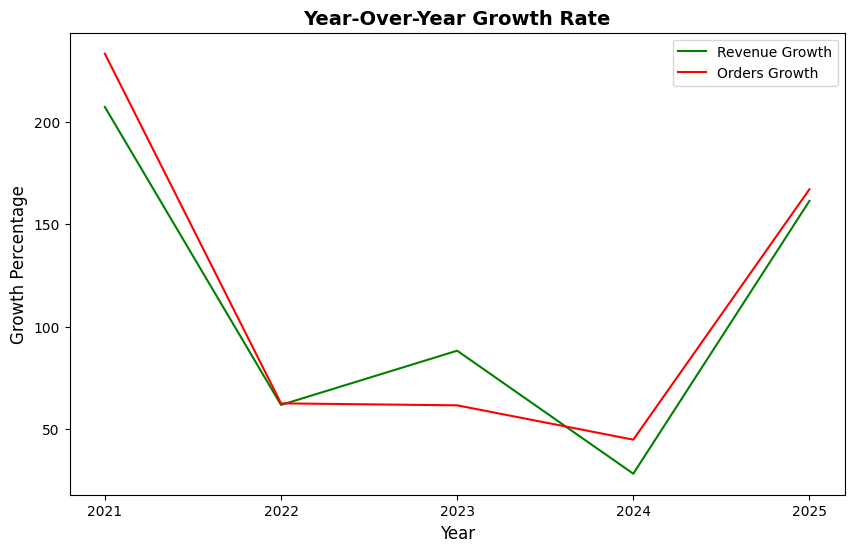

In [ ]:
years = result_growth['Year'].tolist()
revenue_growth = result_growth['Revenue_YoY_Growth_Pct'].tolist()
orders_growth = result_growth['Orders_YoY_Growth_Pct'].tolist()

#crate the plot
plt.figure(figsize=(10,6))
plt.plot(years, revenue_growth,color ="green",label="Revenue Growth")
plt.plot(years, orders_growth,color ="red",label="Orders Growth")
plt.xlabel("Year",fontsize = 12 )
plt.ylabel("Growth Percentage",fontsize =12)
plt.title("Year-Over-Year Growth Rate",fontsize = 14,fontweight ="bold")
plt.legend()
plt.show()

# 🎯 Phase 2: RFM Analysis & Strategic Segmentation

### The Strategic Value of RFM in Retail
In a retail environment, not all customers are created equal. **RFM (Recency, Frequency, Monetary)** analysis is the gold standard for retail analytics because it moves beyond aggregate sales to look at individual human behavior.

* **The Customer Acquisition Paradox:** It is a well-known marketing reality that **acquiring a new customer is 5 to 25 times more expensive than retaining an existing one.** By identifying our most loyal customers, we can focus our budget on retention—maximizing ROI and reducing the "churn" that drains retail profits.

### Our Methodology: Data-Driven Thresholds
Instead of choosing arbitrary numbers to define a "good" customer, we allow the data to dictate the boundaries through **quintile distribution (20% groupings)**:

* **High (Top 20%):** The elite tier. These are the customers driving the majority of the revenue and brand engagement.
* **Medium (Middle 60%):** The core engine of the business. These customers are steady but have the potential to be "upsold" to the High tier.
* **Low (Bottom 20%):** The dormant or low-value tier. These customers may require aggressive re-engagement or may not be worth significant marketing spend.



---

### 💰 Monetary Value Calculation & Strategic Tiering

This section initiates the RFM process by quantifying the "Monetary" (M) component, transitioning from raw transaction data to a structured customer value model:

* **Data Sanitization & Fusion:** Ensures 1:1 join integrity by stripping whitespace from `Product_ID` and merging the **Orders** and **Products** datasets to retrieve accurate unit pricing.
* **Revenue Attribution:** Calculates line-level revenue to determine the total lifetime gross expenditure for each unique customer.
* **Quantile-Based Tiering (The 20/60/20 Rule):** Implementation of a data-driven classification system using quintiles:
    * **High (Top 20%):** Customers in the 5th quintile with the highest spend.
    * **Medium (Middle 60%):** Customers in the 2nd, 3rd, and 4th quintiles representing the core revenue base.
    * **Low (Bottom 20%):** Customers in the 1st quintile with minimal financial contribution.
* **Distribution Validation:** A final audit of the counts to ensure the customer base is correctly balanced across the defined strategic tiers.

In [ ]:
# Clean the Product_ID in both tables to be safe
products['Product_ID'] = products['Product_ID'].astype(str).str.strip()

#   merge tables "orders and prodcuts"
orders_with_prices = orders.merge(
    products[["Product_ID", "Price"]],
    on="Product_ID",
    how="left"
)

# calculate Revenu per line
orders_with_prices["Revenue"] = orders_with_prices["Quantity"] * orders_with_prices["Price"]

#aggregate by customer
customer_spendings = orders_with_prices.groupby("Customer_ID").agg({'Revenue' : 'sum' }   ).reset_index()
#change columns names
customer_spendings.columns= ["Customer_ID","Total_Spent"]
print("customers spending")
print(customer_spendings.head(10))
print(f"\nTotal Customers: {len(customer_spendings)}") ## it should equal number of customers


# create Mentary levels categories "Quantiles will 20% per packet"
# Calculate quintiles (20% buckets)
customer_spendings['Monetary_Quintile'] = pd.qcut(
    customer_spendings['Total_Spent'],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Map quintiles to levels: Top 20% = High, Middle 60% = Medium, Bottom 20% = Low
def assign_monetary_level(quintile):
    if quintile == 5:
        return 'High'
    elif quintile in [2, 3, 4]:
        return 'Medium'
    else:  # quintile == 1
        return 'Low'

customer_spendings['Monetary_Level'] = customer_spendings['Monetary_Quintile'].apply(assign_monetary_level)
print(customer_spendings.head(10))

print("\n Distribution of Monetary Levels:")
print(customer_spendings['Monetary_Level'].value_counts().sort_index())

customers spending
  Customer_ID  Total_Spent
0   CUST_0001      7157.06
1   CUST_0002      8524.00
2   CUST_0003     19000.94
3   CUST_0004     10210.63
4   CUST_0005     22411.65
5   CUST_0006     16770.67
6   CUST_0007     17643.61
7   CUST_0008     14525.05
8   CUST_0009      9269.89
9   CUST_0010     11463.90

Total Customers: 100
  Customer_ID  Total_Spent Monetary_Quintile Monetary_Level
0   CUST_0001      7157.06                 2         Medium
1   CUST_0002      8524.00                 2         Medium
2   CUST_0003     19000.94                 5           High
3   CUST_0004     10210.63                 2         Medium
4   CUST_0005     22411.65                 5           High
5   CUST_0006     16770.67                 5           High
6   CUST_0007     17643.61                 5           High
7   CUST_0008     14525.05                 4         Medium
8   CUST_0009      9269.89                 2         Medium
9   CUST_0010     11463.90                 3         Medium

 

### 🔄 Frequency Analysis & Engagement Tiering

This section quantifies the "Frequency" (F) component of the RFM model, measuring how often customers interact with the brand:

* **Transaction Aggregation:** Groups order data by unique Customer IDs to calculate the total count of distinct purchase events, distinguishing loyal repeat buyers from one-time shoppers.
* **Frequency Distribution:** Utilizes quintile-based binning to categorize the customer base. Note the use of `duplicates='drop'`, which intelligently handles cases where many customers share the same low order count.
* **Engagement Classification:**
    * **High (Top 20%):** Our most frequent visitors and habitual shoppers.
    * **Medium (Middle 60%):** Occasional customers who provide steady operational volume.
    * **Low (Bottom 20%):** Customers with minimal transaction history, potentially at the start of their journey or at risk of churn.
* **Volume Profiling:** Summarizes the distribution to ensure the tiers accurately reflect the purchasing tempo of the entire customer base.

In [ ]:
# get custoemer frequency
customer_frequency = orders.groupby("Customer_ID").agg({'Order_ID':"nunique"}).reset_index()
#rename columns
customer_frequency.columns = ['Customer_ID','Total_Orders']
print("Customer Frequency : ")
print(customer_frequency.head(10))

# create Frequency levels categories "Quantiles will 20% per packet"
customer_frequency['Frequency_Quintile'] = pd.qcut(
    customer_frequency['Total_Orders'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop' )

# Map quintiles to levels: Top 20% = High, Middle 60% = Medium, Bottom 20% = Low
def assign_frequency_level(quintile):
    if quintile == 5:
        return 'High'
    elif quintile in [2, 3, 4]:
        return 'Medium'
    else:  # quintile == 1
        return 'Low'

customer_frequency['Frequency_Level'] = customer_frequency['Frequency_Quintile'].apply(assign_frequency_level)
print(customer_frequency.head(10))
print("\n Distribution of Frequency Levels:")
print(customer_frequency['Frequency_Level'].value_counts().sort_index())

Customer Frequency : 
  Customer_ID  Total_Orders
0   CUST_0001             6
1   CUST_0002             6
2   CUST_0003             9
3   CUST_0004             7
4   CUST_0005            11
5   CUST_0006            13
6   CUST_0007            11
7   CUST_0008             9
8   CUST_0009             7
9   CUST_0010             6
  Customer_ID  Total_Orders Frequency_Quintile Frequency_Level
0   CUST_0001             6                  2          Medium
1   CUST_0002             6                  2          Medium
2   CUST_0003             9                  4          Medium
3   CUST_0004             7                  2          Medium
4   CUST_0005            11                  5            High
5   CUST_0006            13                  5            High
6   CUST_0007            11                  5            High
7   CUST_0008             9                  4          Medium
8   CUST_0009             7                  2          Medium
9   CUST_0010             6             

### 🕒 Recency Analysis & Retention Baseline

This section completes the RFM framework by calculating the "Recency" (R) component, which serves as the most critical indicator of current customer engagement and potential churn:

* **Temporal Normalization:** Converts raw order dates into standardized `datetime` objects to enable precise mathematical operations.
* **Reference Point Calibration:** Establishes a "Snapshot Date" based on the most recent transaction in the dataset, providing a baseline for calculating the "days since last purchase."
* **Recency Quantile Inversion:** Implements an inverse scoring logic where **fewer days** elapsed since the last order result in a **higher quintile score**. This ensures that our "High" tier reflects the most recently active customers.
* **Churn Risk Identification:** * **High (Top 20%):** Recently active shoppers with the highest immediate conversion potential.
    * **Medium (Middle 60%):** Customers who are still within a standard purchasing window.
    * **Low (Bottom 20%):** Dormant customers who have not interacted with the brand for an extended period, signaling a high risk of churn.

In [ ]:
# convert order_date to be datetime
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])
# max date or last date of purchase
reference_date = orders['Order_Date'].max()
print(f"Reference Date For Recency : {reference_date}")

#most recent order date for each customer
customer_recency = orders.groupby("Customer_ID").agg({'Order_Date': 'max'}).reset_index()
#rename columns names
customer_recency.columns = ['Customer_ID','Last_Order_Date']
#calculate date since last order
customer_recency['Recency_Days']=(reference_date - customer_recency['Last_Order_Date']).dt.days
print("\nCusomers Resency")
print(customer_recency.head(10))

# create Resency levels categories "Quantiles will 20% per packet"
customer_recency['Recency_Quintile'] = pd.qcut(
    customer_recency['Recency_Days'],
    q=5,
    labels=[5, 4, 3, 2, 1],  # REVERSED: lowest days = quintile 5 (best)
    duplicates='drop'
)

# Map quintiles to levels: Quintile 5 = High (recent), Middle = Medium, Quintile 1 = Low (old)
def assign_recency_level(quintile):
    if quintile == 5:
        return 'High'
    elif quintile in [2, 3, 4]:
        return 'Medium'
    else:  # quintile == 1
        return 'Low'

customer_recency['Recency_Level'] = customer_recency['Recency_Quintile'].apply(assign_recency_level)
print("\nCustomer Recency with Quantiles:")
print(customer_recency.head(10))
print("\n Distribution of Recency Levels:")
print(customer_recency['Recency_Level'].value_counts().sort_index())

Reference Date For Recency : 2025-12-31 00:00:00

Cusomers Resency
  Customer_ID Last_Order_Date  Recency_Days
0   CUST_0001      2025-12-02            29
1   CUST_0002      2025-03-20           286
2   CUST_0003      2025-12-25             6
3   CUST_0004      2025-07-14           170
4   CUST_0005      2025-10-27            65
5   CUST_0006      2025-12-24             7
6   CUST_0007      2025-04-24           251
7   CUST_0008      2025-12-23             8
8   CUST_0009      2025-12-17            14
9   CUST_0010      2025-12-23             8

Customer Recency with Quantiles:
  Customer_ID Last_Order_Date  Recency_Days Recency_Quintile Recency_Level
0   CUST_0001      2025-12-02            29                4        Medium
1   CUST_0002      2025-03-20           286                1           Low
2   CUST_0003      2025-12-25             6                5          High
3   CUST_0004      2025-07-14           170                2        Medium
4   CUST_0005      2025-10-27           

### 🧩 Multi-Dimensional RFM Integration & Behavioral Segmentation

This final analytical stage synthesizes individual metrics into a unified behavioral model, transforming raw data into actionable business intelligence:

* **Data Synthesis:** Consolidates the independent **Recency**, **Frequency**, and **Monetary** tables into a master RFM matrix, providing a 360-degree view of each customer's lifecycle and value.
* **Composite Level Generation:** Creates a "RFM_Combined" string (e.g., *HighHighHigh*) to facilitate multi-criteria pattern matching, ensuring that customer classification accounts for all behavioral dimensions simultaneously.
* **Strategic Persona Mapping:** Translates technical data clusters into strategic business segments:
    * **Champions:** The elite tier of high-value, high-frequency, and recently active customers.
    * **At Risk (Big Spenders):** Formerly high-value customers who have not made a purchase recently, signaling an urgent need for re-engagement.
    * **Potential Loyalists:** The "catch-all" segment of emerging customers who show promise but require nurturing to transition into the higher tiers.
* **Segment Profiling:** Calculates average performance metrics (Spend, Volume, and Recency) per segment to validate the model's accuracy and provide clear benchmarks for targeted marketing strategies.

In [ ]:
# Merge all RFM components
rfm_table = customer_spendings[['Customer_ID', 'Total_Spent', 'Monetary_Level']].copy()
#add Frequency Data
rfm_table = rfm_table.merge(
    customer_frequency[['Customer_ID', 'Total_Orders', 'Frequency_Level']],
    on='Customer_ID',
    how='left'
)
#add Recency Data
rfm_table = rfm_table.merge(
    customer_recency[['Customer_ID', 'Recency_Days', 'Recency_Level']],
    on='Customer_ID',
    how='left'
)

# Reorder columns
rfm_table = rfm_table[[
    'Customer_ID',
    'Total_Spent',
    'Monetary_Level',
    'Total_Orders',
    'Frequency_Level',
    'Recency_Days',
    'Recency_Level'
]]

print("RFM Table (before segmentation):")
print(rfm_table.head(15))

#combine RFM levels
rfm_table['RFM_Combined'] = (
    rfm_table['Recency_Level'] +
    rfm_table['Frequency_Level'] +
    rfm_table['Monetary_Level']
)


# Step 2: Define cateogries
segment_map = {
    'HighHighHigh': 'Champions',            # Best at everything
    'HighHighMedium': 'Loyal Customers',    # Buy often, spend okay
    'MediumHighMedium': 'Loyal Customers',  # Steady regulars
    'LowHighLow': 'Loyal (Low Spenders)',   # High F, others Low
    'HighLowLow': 'New Customers',          # Just started, haven't spent much yet
    'LowLowHigh': 'At Risk (Big Spenders)', # Spent a lot once, but haven't been back
    'LowLowLow': 'Lost Customers',          # Haven't been back, didn't spend, didn't visit
}

# Step 3: Apply the map
rfm_table['Segment'] = rfm_table['RFM_Combined'].apply(
    lambda x: segment_map.get(x, 'Potential Loyalists')
)

print("\n" + "="*80)
print("FINAL RFM TABLE WITH SEGMENTS")
print("="*80)
print(rfm_table.head(20))

print("\n" + "="*80)
print("Segment Distribution:")
print("="*80)
print(rfm_table['Segment'].value_counts())

print("\n" + "="*80)
print("Average Metrics by Segment:")
print("="*80)
print(rfm_table.groupby('Segment')[['Total_Spent', 'Total_Orders', 'Recency_Days']].mean().round(2))

RFM Table (before segmentation):
   Customer_ID  Total_Spent Monetary_Level  Total_Orders Frequency_Level  \
0    CUST_0001      7157.06         Medium             6          Medium   
1    CUST_0002      8524.00         Medium             6          Medium   
2    CUST_0003     19000.94           High             9          Medium   
3    CUST_0004     10210.63         Medium             7          Medium   
4    CUST_0005     22411.65           High            11            High   
5    CUST_0006     16770.67           High            13            High   
6    CUST_0007     17643.61           High            11            High   
7    CUST_0008     14525.05         Medium             9          Medium   
8    CUST_0009      9269.89         Medium             7          Medium   
9    CUST_0010     11463.90         Medium             6          Medium   
10   CUST_0011      6656.77            Low             4             Low   
11   CUST_0012      7438.28         Medium             

### 📊 Strategic Distribution & Segment Composition Analysis

This visualization provides a quantitative breakdown of the customer base, enabling stakeholders to visualize the relative size and impact of each behavioral cohort:

* **Segment Hierarchy:** Ranks customer segments from largest to smallest, immediately identifying which personas dominate the current business landscape.
* **Volume Quantification:** Incorporates direct data labels on each bar to provide precise headcounts for each segment, facilitating accurate resource allocation and marketing spend projections.
* **Visual Priority Mapping:** Utilizes a gradient color scheme to establish a clear visual hierarchy, allowing for rapid identification of the primary segments requiring immediate strategic attention.
* **Operational Readiness:** Provides a data-driven foundation for selecting the focus of retention campaigns (e.g., addressing "At Risk" counts) or expansion efforts (e.g., scaling "Potential Loyalists").

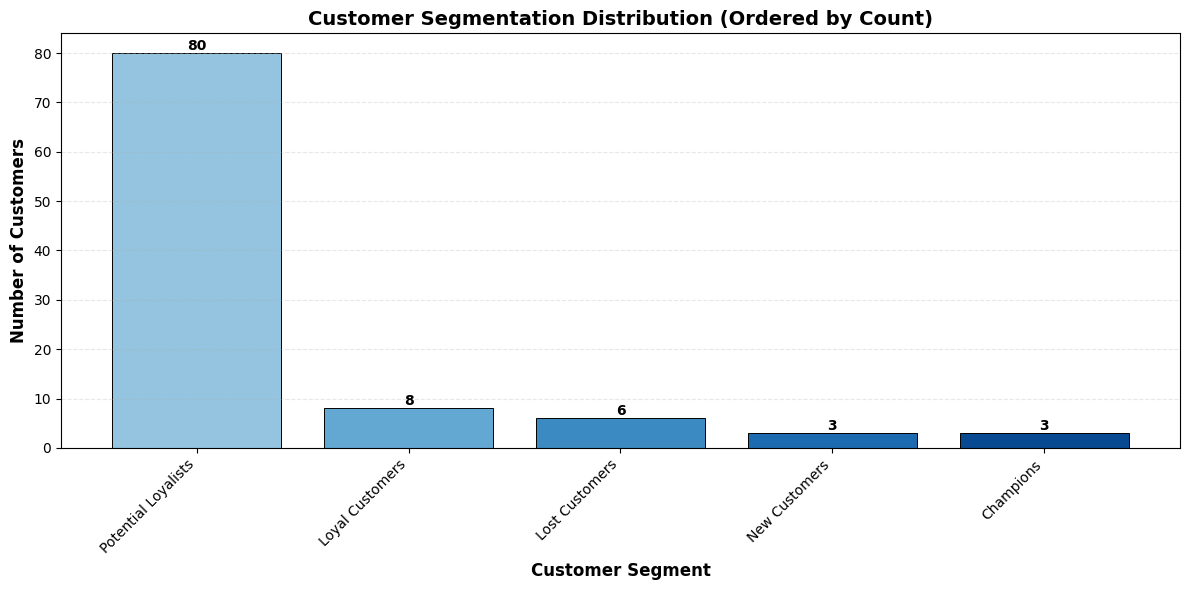

In [ ]:
# Get segment counts and sort from highest to lowest
segment_counts = rfm_table['Segment'].value_counts().sort_values(ascending=False)

# Create gradient colors (baby blue gradient)
n_segments = len(segment_counts)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, n_segments))  # Baby blue gradient

# Create the plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    range(len(segment_counts)),
    segment_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.7
)

# Set x-axis labels
plt.xticks(range(len(segment_counts)), segment_counts.index, rotation=45, ha='right')

# Labels and title
plt.xlabel('Customer Segment', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.title('Customer Segmentation Distribution (Ordered by Count)', fontsize=14, fontweight='bold')

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 🚀 Strategic Analysis & Tactical Recommendations

### 📊 Segment-Specific Observations

Based on the visualized distribution showing **80 Potential Loyalists** and a smaller core of **Champions**, the following actions are recommended:

| Segment | Observation | Data-Driven Action |
| :--- | :--- | :--- |
| ## **Potential Loyalists** | **80% of your base.** This is your "Growth Engine." They have interacted but haven't fully committed to a habit yet. | **Priority #1:** Focus 70% of your marketing effort here. Use "Next Purchase" discounts or loyalty "stamp cards" to move them into the Loyal tier. |
| ## **Champions & Loyalists** | Small but mighty (11 total). They represent your most stable revenue but are a **critically small group**. | **Risk Mitigation:** You are overly dependent on a few individuals. Reward them with "VIP-only" perks to ensure zero churn, as losing one would hurt your totals. |
| ## **Lost Customers** | 6 customers have already slipped away. | **Efficiency Gain:** Send one final "Win Back" offer. If they don't respond, stop spending marketing dollars on them and pivot to the Potential Loyalists. |
| ## **New Customers** | Only 3 new acquisitions showing up in the recent cycle. | **Pipeline Growth:** Your acquisition rate is currently lower than your retention potential. It is time to test new top-of-funnel ads or referral programs. |

---

### 💡 Executive Summary
Data shows a **"Heavy Middle"** distribution. This is a massive opportunity; you don't need to find new strangers to buy from you—you just need to convert the 80 people who already know you into repeat shoppers.

**Next Steps:**
* Extracting the list of `Customer_ID`s for the **Potential Loyalists**.
* Launching a "Second Purchase" incentive campaign.
* Monitoring the conversion rate of this segment over the next 30 days.